In [11]:
import uproot
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
from pathlib import Path
import mplhep
plt.style.use(mplhep.style.CMS)
def get_hists(dc: str):
    with uproot.open(dc) as f:
        hists = { n.strip(';1') : (f[n].values(), np.arange(0,len(f[n].axis().edges()))) for n in f.classnames()}
    sig = hists.pop('ggHH_kl_1_kt_1_bbww')
    asimov = hists.pop('asimov')
    hists.pop("ggHH_kl_0_kt_1_bbww")
    hists.pop("ggHH_kl_2p45_kt_1_bbww")
    hists.pop("ggHH_kl_5_kt_1_bbww")
    hists.pop("ggHH_kl_0_kt_1_bbtautau")
    hists.pop("ggHH_kl_1_kt_1_bbtautau")
    hists.pop("ggHH_kl_2p45_kt_1_bbtautau")
    hists.pop("ggHH_kl_5_kt_1_bbtautau")
    return sig, hists

In [12]:
%config InlineBackend.figure_format = 'retina'

In [13]:
def get_color_dict(test_dc) -> dict[str, str]:
    mplcolors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    names = list(get_hists(test_dc)[1].keys())
    colors = { names[i]: mplcolors[i%len(mplcolors)] for i in range(len(names)) }
    return colors

Workdir: /eos/user/a/anunezde/Z_OUTPUT_eos/Final_Model/NNInf_1017_roster_0910
Model name: multi_HH_ttbar_tW


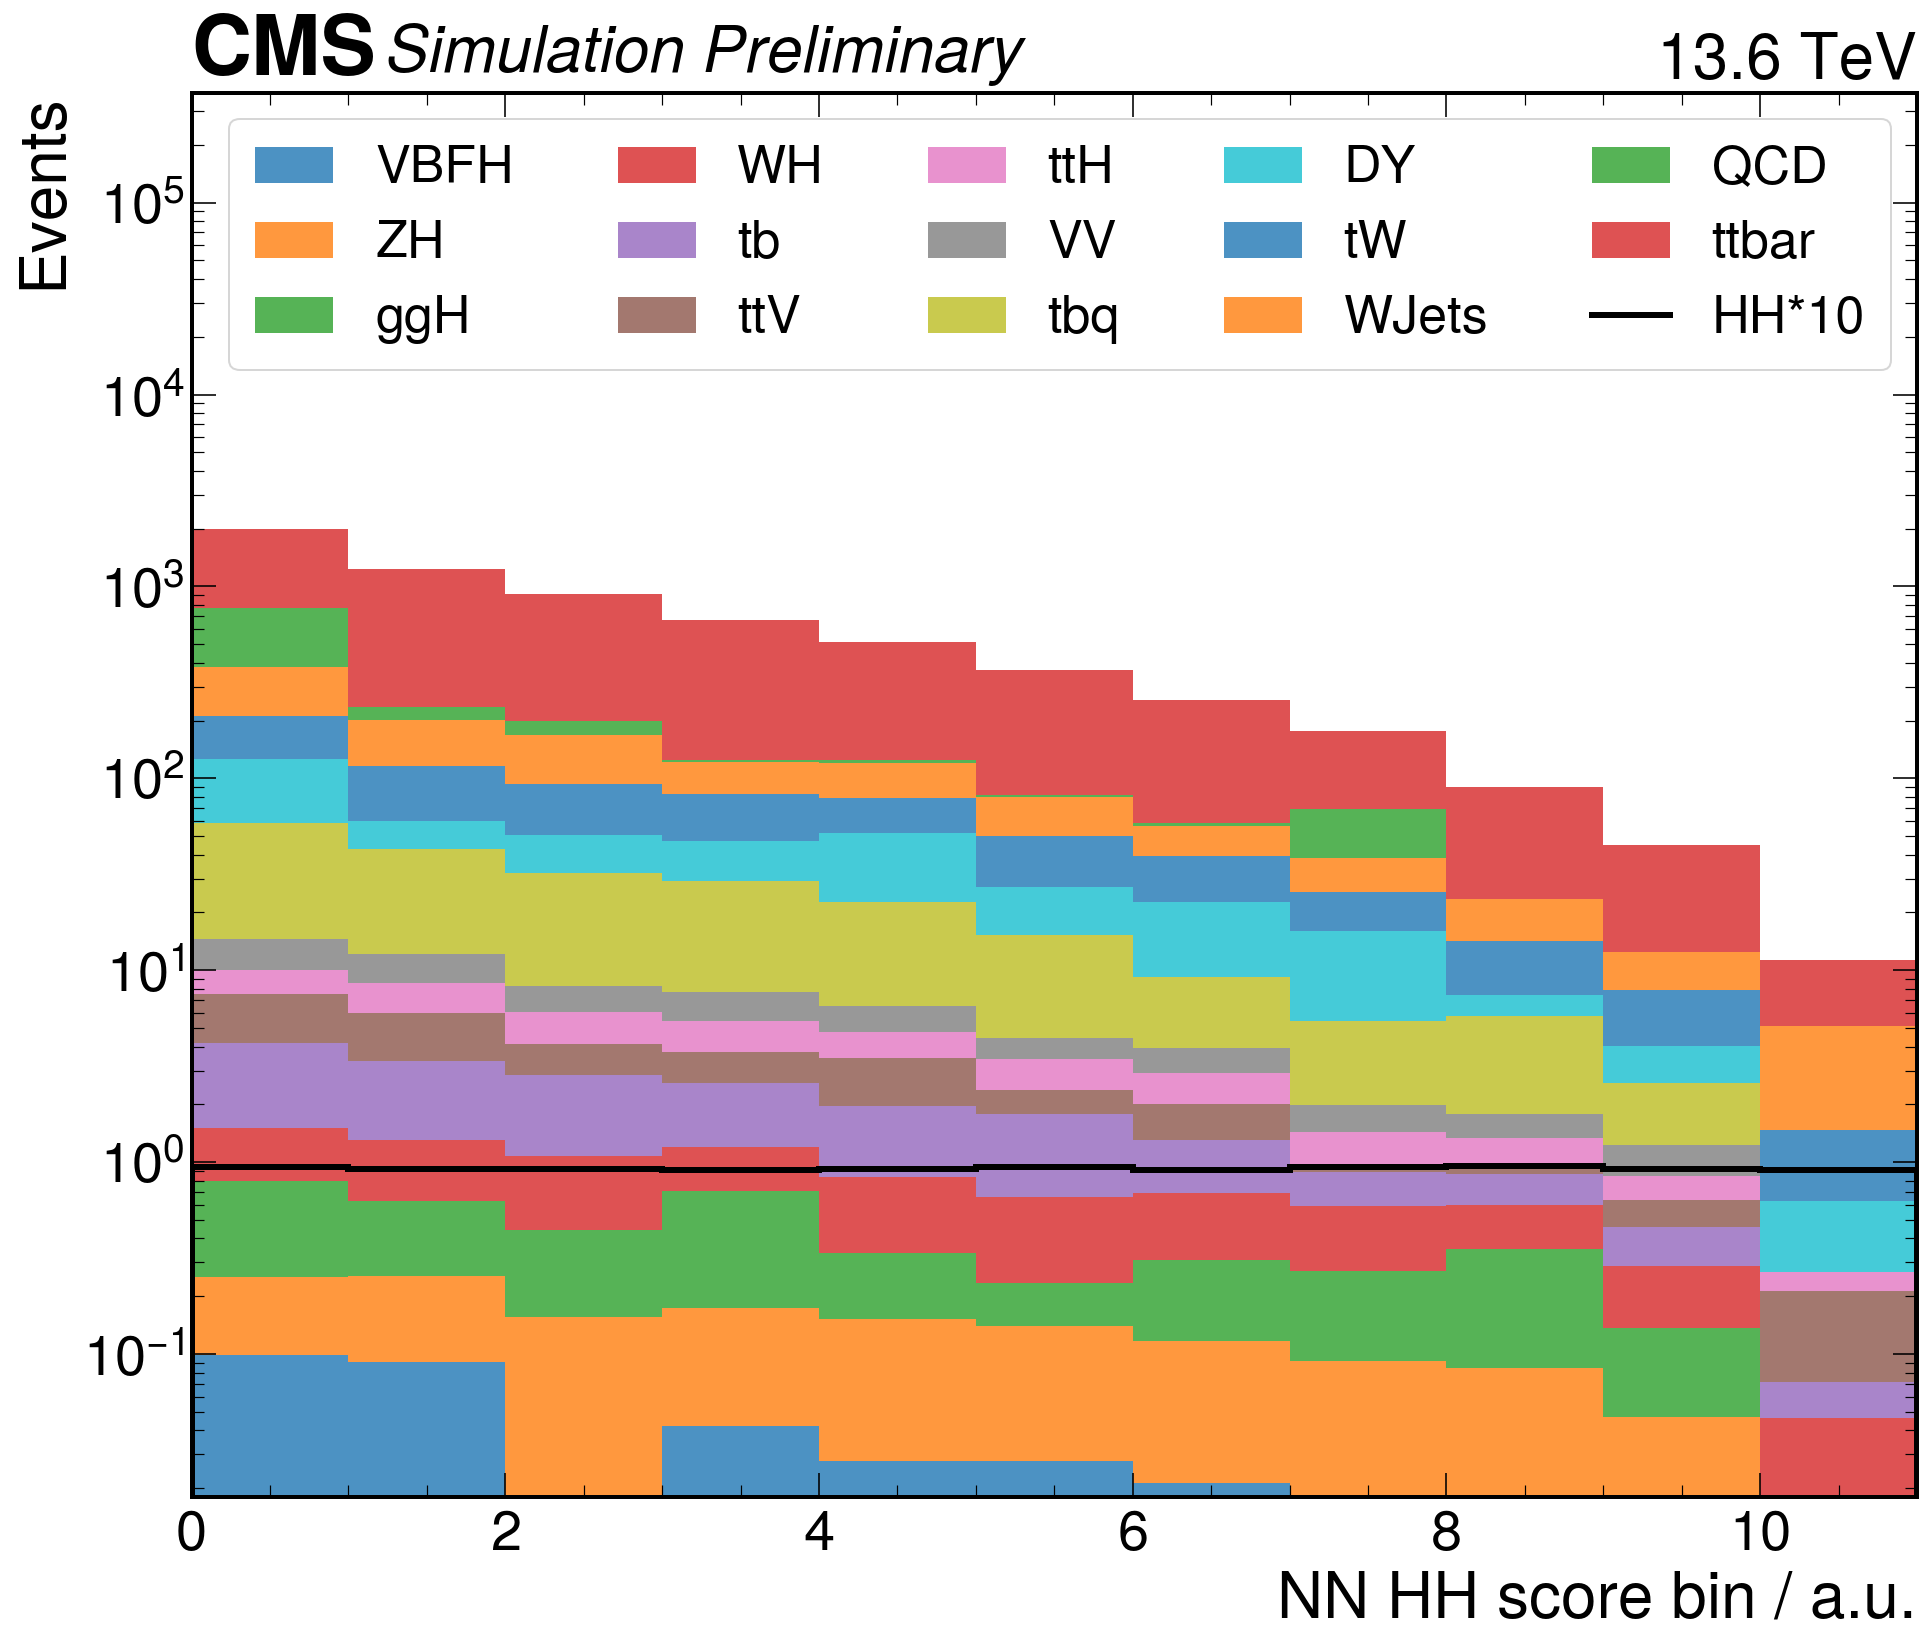

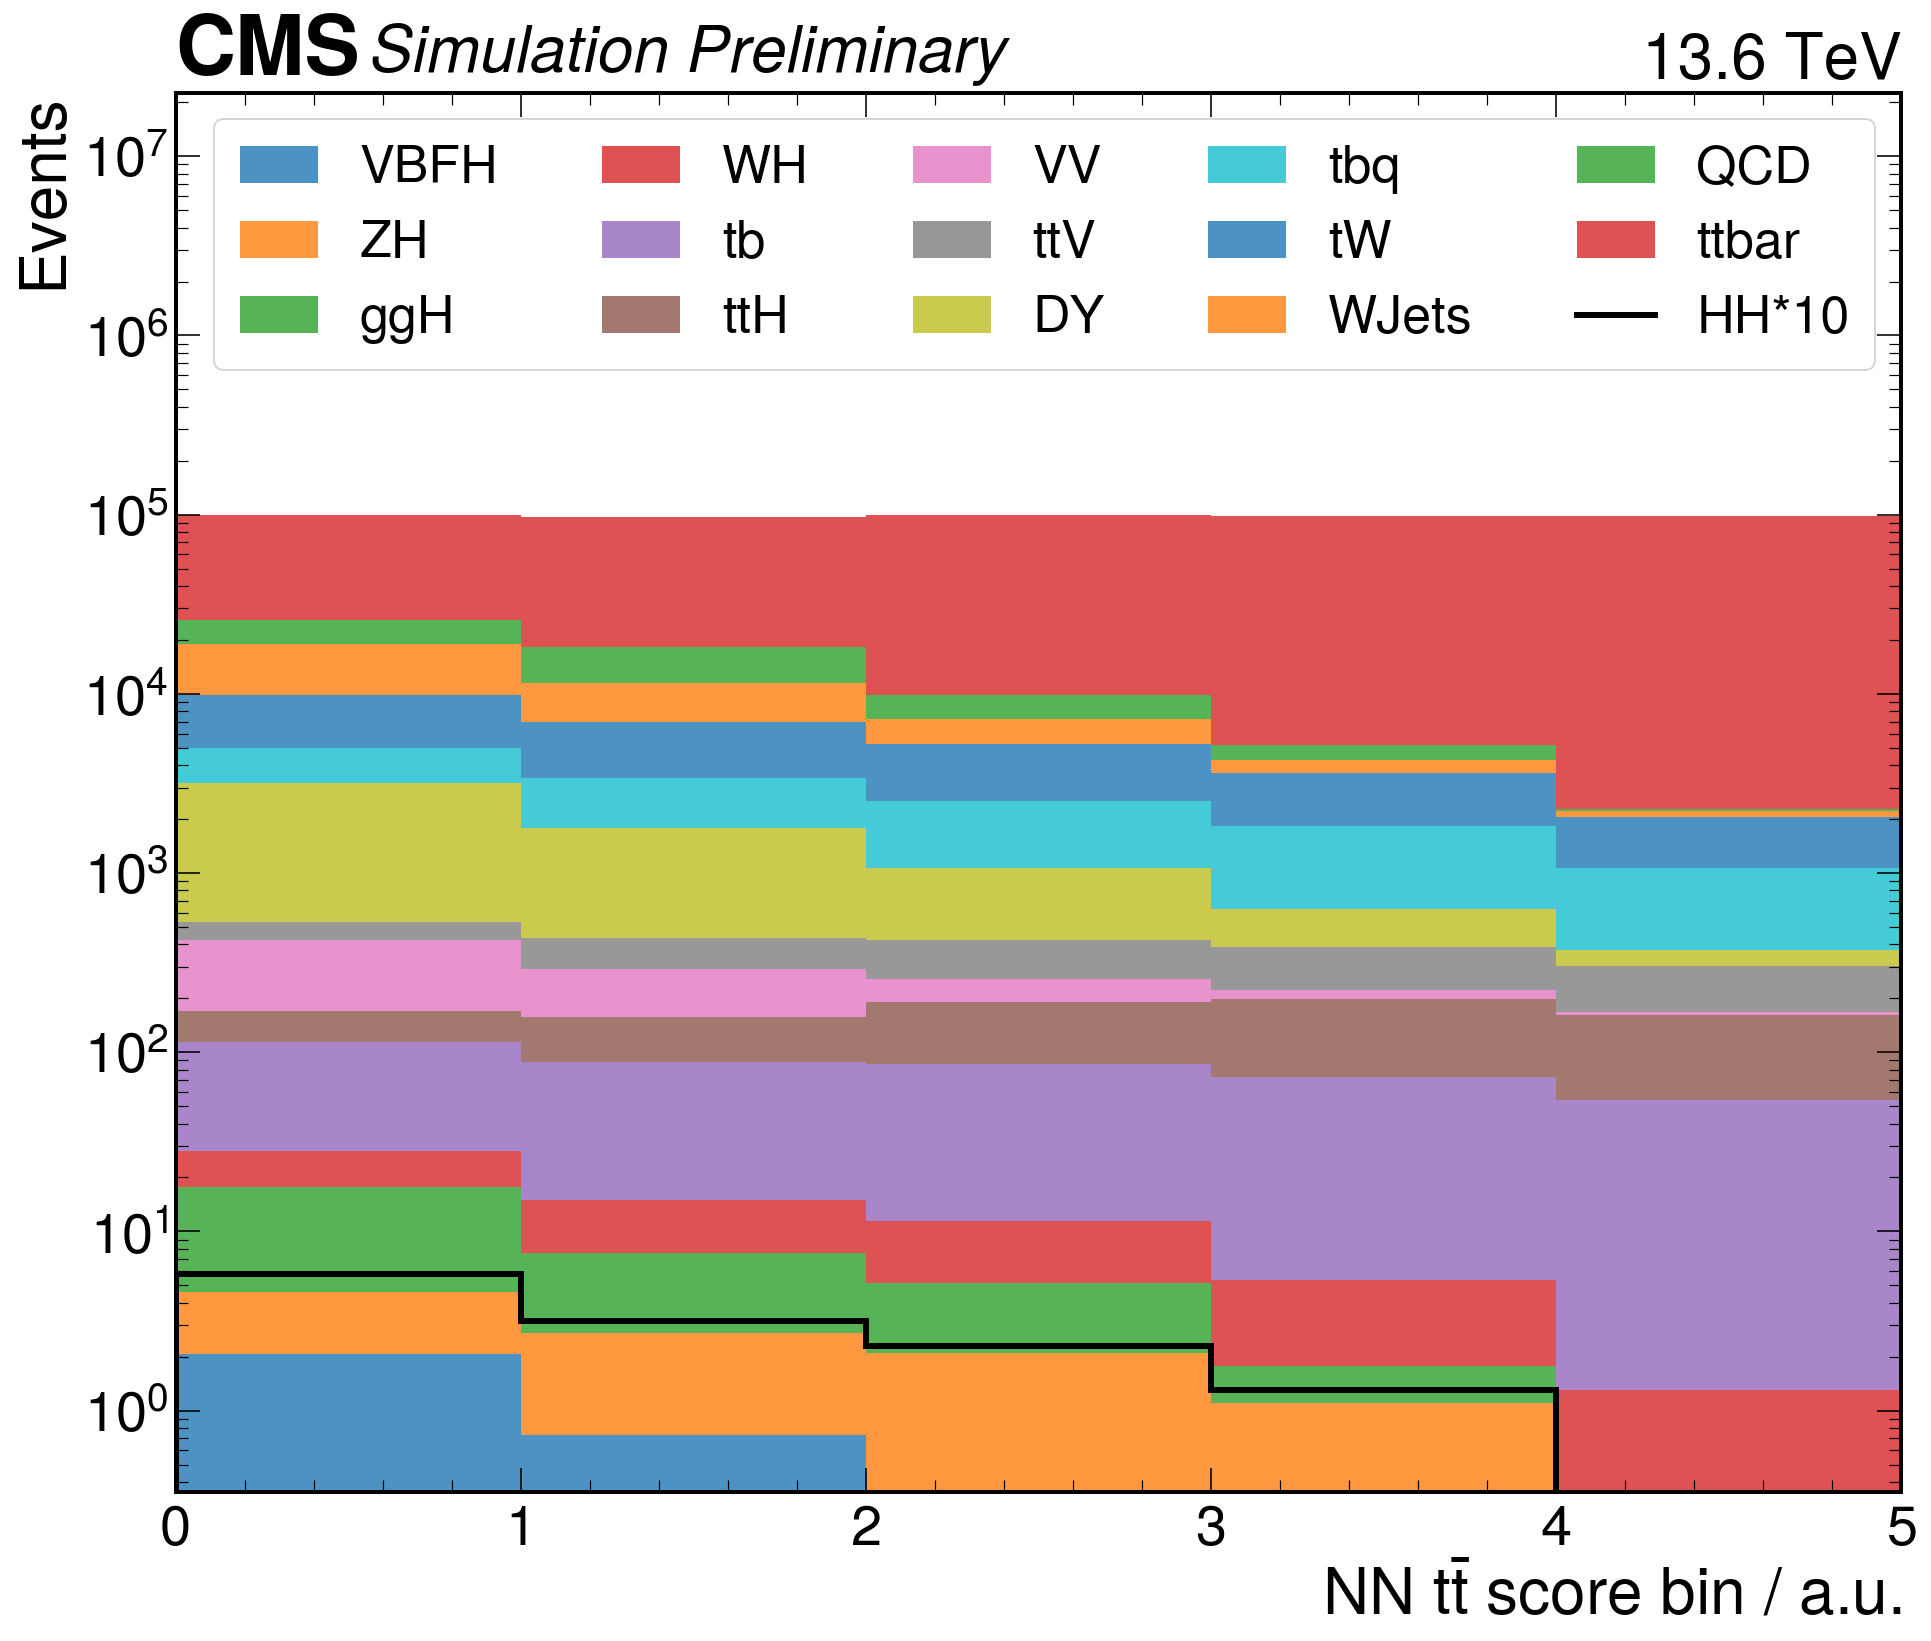

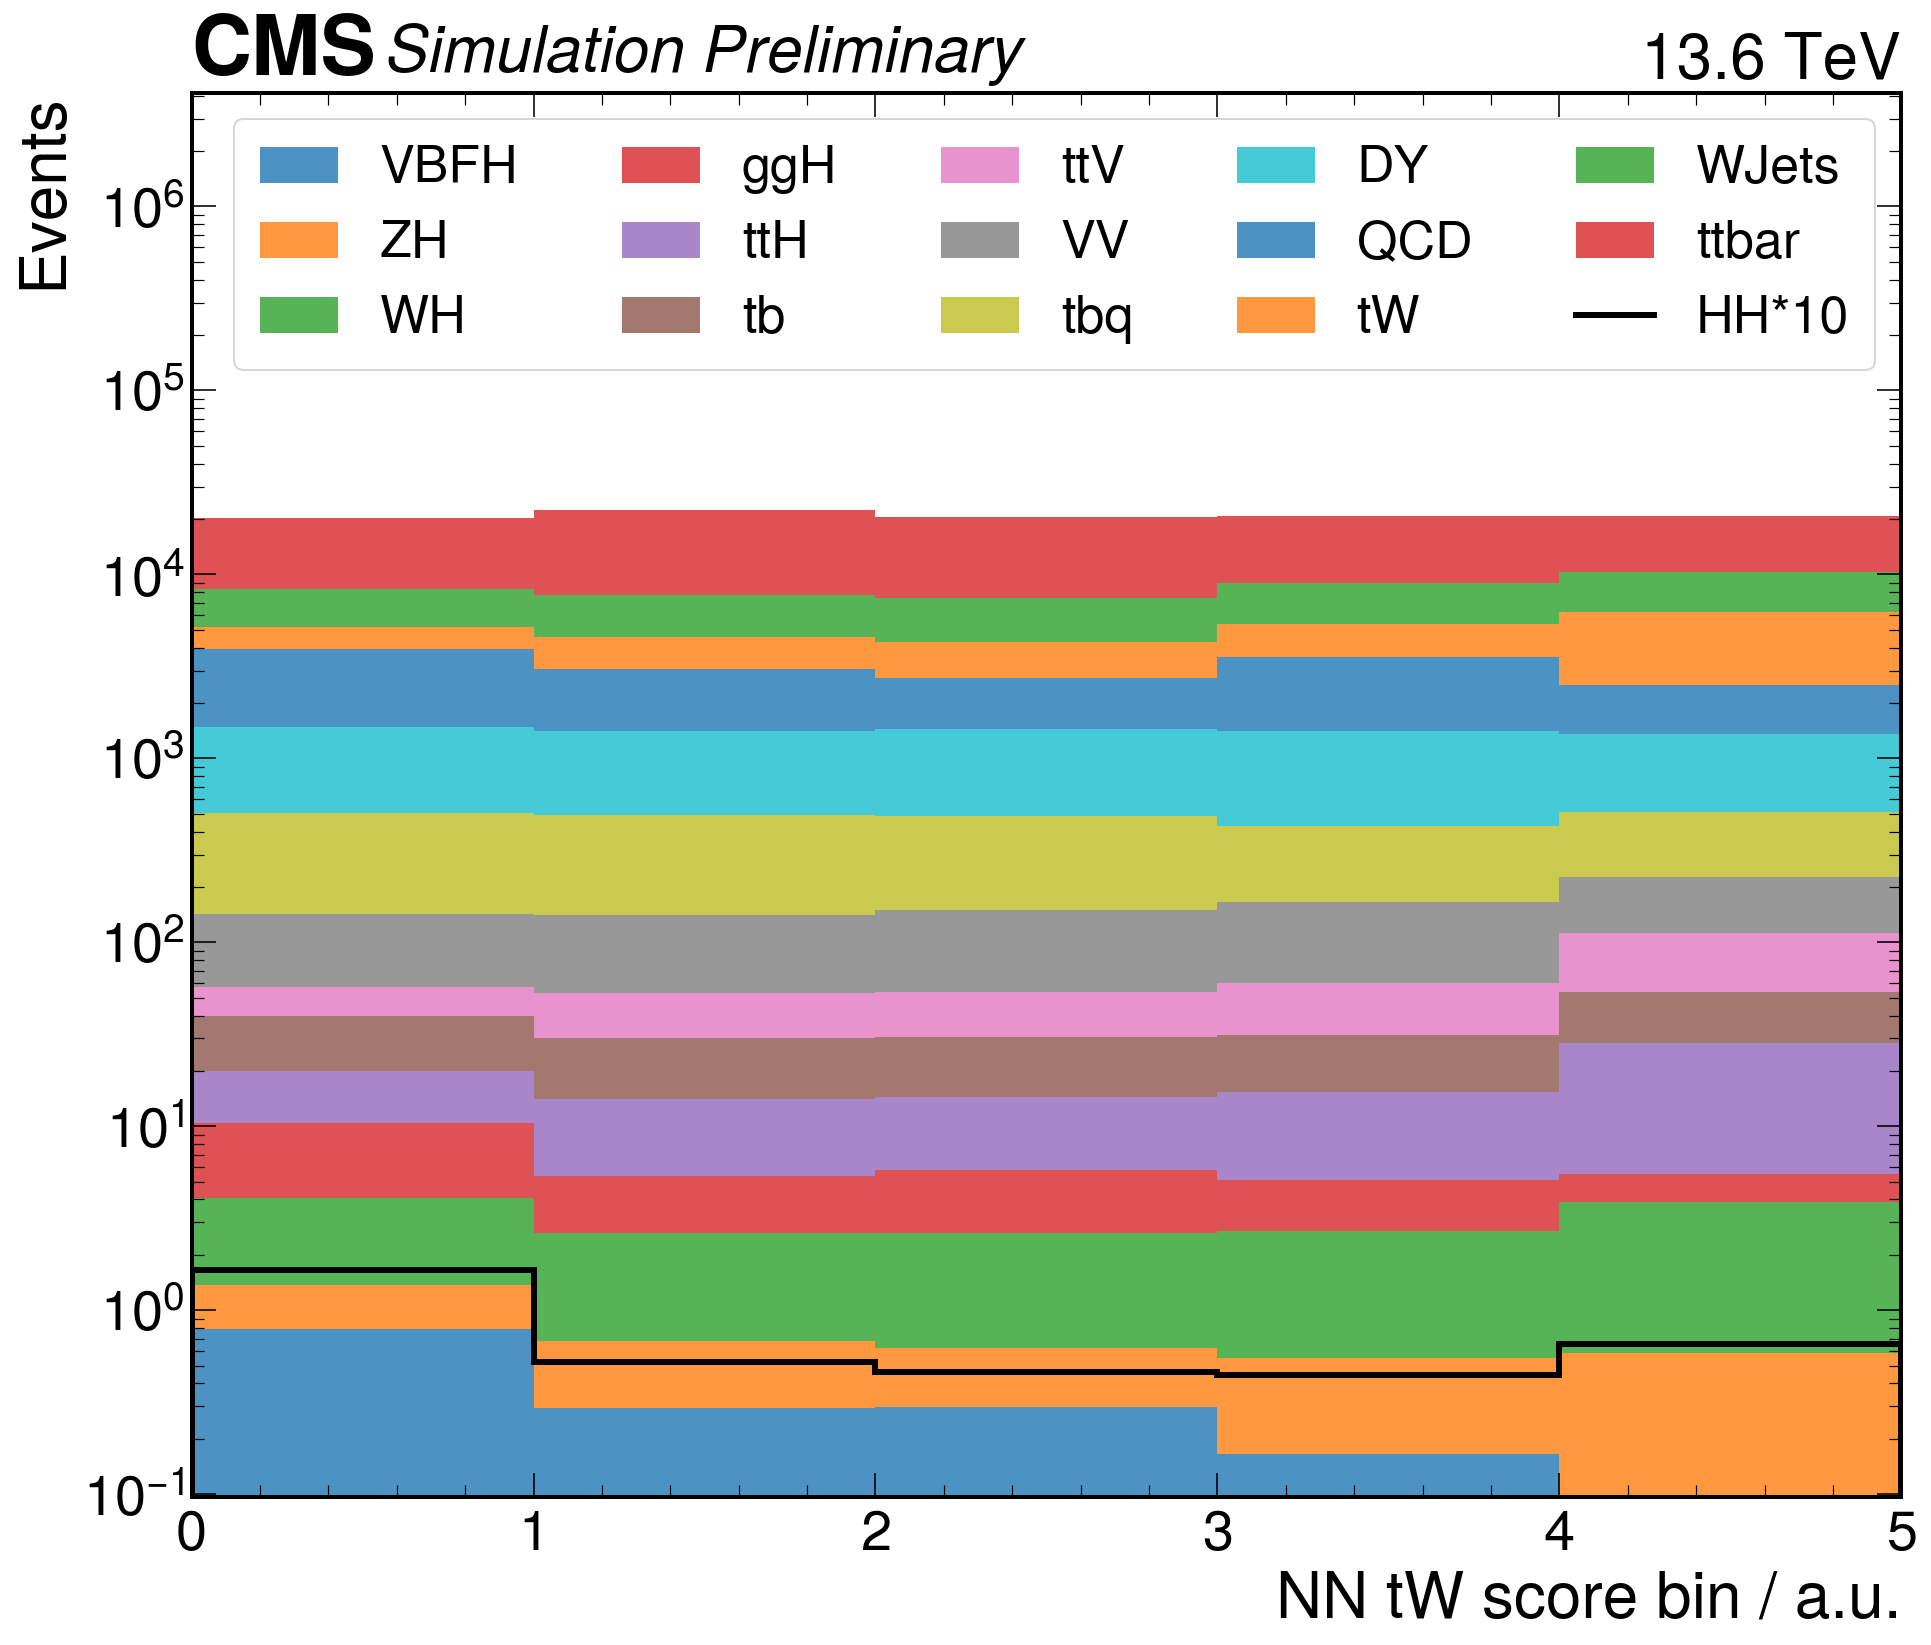

In [ ]:
signal_multiplier = 10

workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Final_Model/NNInf_1017_roster_0910')
model_name = "multi_HH_ttbar_tW"
model_fit_dir = workdir / "fits_new" / model_name
signal_dc: str = model_fit_dir / "2022" / "SL_4j_resolved" / 'HH' / "HH_score.root"
ttbar_dc: str = model_fit_dir / "2022" / "SL_4j_resolved" / 'ttbar' / "ttbar_score.root"
tW_dc: str = model_fit_dir / "2022" / "SL_4j_resolved" / 'tW' / "tW_score.root"

data_files = [
    (signal_dc, r'NN HH score bin / a.u.', 'HH'),
    (ttbar_dc, r'NN t$\bar t$ score bin / a.u.', 'ttbar'),
    (tW_dc, r'NN tW score bin / a.u.', 'tW')
]

print(f'Workdir: {workdir}')
print(f'Model name: {model_name}')

OUTDIR = workdir / 'prefit_plots' / model_name / 'SL_4j_resolved'
OUTDIR.mkdir(exist_ok=True)
legend_fs = 26
label_fs = 32
tick_fs = 28
for dc, xlabel, process in data_files:

    fig, ax = plt.subplots(figsize=(14,12))
    sig, bkg_dict = get_hists(dc)
    hep.histplot(list(bkg_dict.values()), ax=ax, histtype='fill', label=bkg_dict.keys(), stack=True, sort='y', alpha=0.8)
    hep.histplot((sig[0]*signal_multiplier, sig[1]), ax=ax, label=f'HH*{signal_multiplier}', lw=3, color='k')

    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=label_fs, loc=0)
    ax.text(1.0, 1.0, "13.6 TeV", transform=ax.transAxes, fontsize=label_fs,
            horizontalalignment='right', verticalalignment='bottom')

    ax.set_yscale('log')

    ax.set_xlim(0,sig[1][-1])
    ax.set_ylim(None, ax.get_ylim()[1]*100)
    
    ax.set_xlabel(xlabel, fontsize=label_fs)
    ax.set_ylabel('Events', fontsize=label_fs)

    ax.tick_params(axis='x', labelsize=tick_fs)
    ax.tick_params(axis='y', labelsize=tick_fs)

    ax.legend(ncol=(len(bkg_dict)+1)//3, loc="upper right", frameon=True, fontsize=legend_fs)

    pdf_path = OUTDIR / f"prefit_{model_name}_{process}.pdf"
    fig.tight_layout()
    plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches='tight')
    plt.show()